# E2-B: a second fresh sample of long logic sentences, scored with the gold-free V0 consensus metric

**The question.** Can we tell whether a candidate first-order-logic (FOL) formalisation of a sentence is faithful **without a gold formula**?
This artifact tests one gold-free score, **V0 = cross-family consensus `c_score_align`**. For each candidate formula it computes

$$V0 = 1 - \frac{\#\{\text{peers from other model families that are z3-equivalent to the candidate}\}}{\#\{\text{other-family peers}\}}$$

(higher = more suspicious). It compares V0 with an LLM judge (gemini flash-lite, rubric A, *disguised* nonce-word view).

**The sample (E2-B).** 400 untouched MALLS-train sentences with ≥25 words and ≥3 conditions. Ten frozen generator slots
(9 model families) produced 4,000 candidates. Labels come from E2's byte-identical solver pipeline, and the scores were sealed before any label was read.

**Status of the original run: PARTIAL, nothing confirmatory.** The run-level API budget ran out, so the blind LLM panel never finished.
Labels are therefore *tier A vs the unaudited MALLS gold*: CORRECT means z3-equivalent to the MALLS gold formula.
With 48 CORRECT / 334 ERROR, the pre-registered tests are NOT TESTABLE. Every label-based number is **exploratory**.

**What this notebook does.**
1. Shows the original `method.py` orchestrator, the pre-registered stage table. Most stages need paid API calls and private venvs.
2. Runs its final CPU-only stage, **`rederive`** (`src/rederive_headline.py`), on a 100-sentence subset (~1,000 candidates). This stage independently re-derives the
   headline numbers from the sealed labels and scores:
   - stratified AUROC of V0 vs the flash-lite judge;
   - a sentence-cluster bootstrap CI on their difference;
   - two placebos that must fail;
   - a label-decoupled V0 recomputed from the raw z3 pairwise matrix;
   - V0 / judge concordance and rename-invariance flips.
3. Plots the demo numbers next to the full-run (400-sentence) values.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# The rederive stage only needs numpy / scipy / scikit-learn (+ matplotlib for the plots) — all pre-installed on Colab.
# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

In [2]:
# --- original imports of method.py ---
from __future__ import annotations

import argparse
import subprocess
import sys
from pathlib import Path

# --- original imports of src/rederive_headline.py (the `rederive` stage) ---
import json
from collections import defaultdict

import numpy as np
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score

# --- notebook-only: plotting ---
import time
import matplotlib.pyplot as plt

## Data loading
`mini_demo_data.json` holds 100 of the 400 E2-B sentences. First come all 31 sentences with at least one CORRECT row in the R_A_UNAUDITED population, then sentences with ERROR rows, in sha1 order.
Each sentence carries:
- its 10 candidates, each with the sealed label row and the sealed score row;
- the eval-2 z3 pairwise-equivalence matrix;
- its rename controls.

The metadata also stores the full-run `analysis/rederive_headline.json`, for comparison.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_An1uy2kF2SjZ/round-5/experiment-12/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
EXAMPLES = data["datasets"][0]["examples"]
FULL_REF = data["metadata"]["full_run_rederive_headline"]  # the original 400-sentence rederive output
print(len(EXAMPLES), "sentences in the demo file;", sum(len(e["candidates"]) for e in EXAMPLES), "candidate rows")

100 sentences in the demo file; 1000 candidate rows


## Configuration
All tunable parameters live here. The original values are in the comments.
- `N_SENTENCES`: how many demo sentences to use (demo file max 100; the original run used all 400).
- `B_BOOT`: sentence-cluster bootstrap replicates for the V0 − flash-lite delta CI.
- `N_PERM`: label permutations for the placebo permutation null.
- `B_PLACEBO`: bootstrap replicates for the two placebo CIs.
- `SEED_*`: seeds, unchanged from the original.

In [5]:
N_SENTENCES = 100   # original: 400 (full E2-B sample; the demo file holds 100)
B_BOOT = 2000        # original: 2000
N_PERM = 200         # original: 200
B_PLACEBO = 1000     # original: 1000
SEED_BOOT, SEED_PERM, SEED_PLACEBO_BOOT, SEED_RANDOM_SCORE, SEED_RANDOM_BOOT = 12345, 7, 99, 3, 5  # original seeds

## 1. The pipeline orchestrator (`method.py`, unchanged)
`method.py` runs the pre-registered pipeline stage by stage. Each stage is a resumable script in `e2bsrc/` or `src/` of the artifact workspace:

| stage | what it does | needs |
|---|---|---|
| `freeze_check` | verifies the 78 frozen E2 files by hash | E2 venv |
| `select` | draws the 400 L25 sentences by E2's sha1 rule | E2 venv |
| `prereg` | writes the frozen pre-registration (refuses to overwrite) | – |
| `generate` | 4,000 candidates from 10 frozen generator slots | **paid API** |
| `labels` | solver labels + blind panel (panel never ran: budget exhausted) | **paid API** |
| `score` | V0/PT (exp-5 z3 code), local features, pairwise matrix, LLM judges, then seal | z3, spaCy, **paid API** |
| `judges` | resume flash-lite / nano / deepseek / frontier judges | **paid API** |
| `finalize` | join labels and scores after both seals, then analyses and tables | exp-5 venv |
| `rederive` | independent re-derivation of every headline number | numpy/scipy/sklearn only |

The code below is copied verbatim. We define it but **do not call `main()`**: the stages expect the artifact's
private venvs (`e2bsrc/.venv`, `exp5src/.venv`), its data tree and an OpenRouter key.
The notebook instead re-implements the last stage, `rederive`, from the loaded data (sections 2-7).

In [6]:
WS = Path(".")  # original: Path(__file__).resolve().parent  (no __file__ inside a notebook; the artifact workspace root)
EPY = str(WS / "e2bsrc/.venv/bin/python")
SPY = str(WS / "exp5src/.venv/bin/python")
STAGES = {
    "freeze_check": [[EPY, "src_e2b/code_freeze_check.py"], "e2bsrc"],
    "select": [[EPY, "src_e2b/select_e2b.py"], "e2bsrc"],
    "prereg": [["python3", "src/prereg_e2b.py"], "."],  # refuses to overwrite the frozen prereg
    "generate": [["bash", "e2bsrc/src_e2b/gen_all.sh"], "."],
    "labels": [["bash", "e2bsrc/src_e2b/run_batches_resume.sh"], "."],
    "score": [["bash", "-c", "bash src/scoring_pipeline.sh && bash src/cpu_chain.sh"], "."],
    "judges": [["bash", "src/judge_resume.sh"], "."],
    "finalize": [["bash", "src/finalize.sh"], "."],
    "rederive": [[SPY, "src/rederive_headline.py"], "."],
}


def run(name: str) -> int:
    cmd, cwd = STAGES[name]
    print(f"=== stage {name}: {' '.join(cmd)} (cwd {cwd})", flush=True)
    return subprocess.run(cmd, cwd=str(WS / cwd)).returncode


def main() -> int:
    ap = argparse.ArgumentParser()
    ap.add_argument("--stage", default="all", choices=["all", *STAGES])
    a = ap.parse_args()
    names = [n for n in STAGES if n != "prereg"] if a.stage == "all" else [a.stage]
    for n in names:
        rc = run(n)
        if rc != 0:
            print(f"stage {n} failed (rc {rc})")
            return rc
    return 0

# Notebook: show what `python3 method.py --stage all` would execute, without executing it.
for n in [n for n in STAGES if n != "prereg"]:
    print(f"{n:13s} -> {' '.join(STAGES[n][0])}   (cwd {STAGES[n][1]})")

freeze_check  -> e2bsrc/.venv/bin/python src_e2b/code_freeze_check.py   (cwd e2bsrc)
select        -> e2bsrc/.venv/bin/python src_e2b/select_e2b.py   (cwd e2bsrc)
generate      -> bash e2bsrc/src_e2b/gen_all.sh   (cwd .)
labels        -> bash e2bsrc/src_e2b/run_batches_resume.sh   (cwd .)
score         -> bash -c bash src/scoring_pipeline.sh && bash src/cpu_chain.sh   (cwd .)
judges        -> bash src/judge_resume.sh   (cwd .)
finalize      -> bash src/finalize.sh   (cwd .)
rederive      -> exp5src/.venv/bin/python src/rederive_headline.py   (cwd .)


## 2. Helpers of the `rederive` stage (verbatim from `src/rederive_headline.py`)
- `strat_auc`: AUROC of a score for predicting **ERROR** (label 1). It is computed within each word bin (25-29, 30-34, …), then averaged with weights n1·n0.
  Long sentences are not compared against short ones.
- `boot_delta`: 95% CI of `strat_auc(a) − strat_auc(b)`. It uses a **cluster bootstrap over sentences**, because the 10 candidates of one sentence are not independent.

In [7]:
def jl(p):
    return [json.loads(l) for l in Path(p).read_text().splitlines() if l.strip()]


def strat_auc(y, s, h):
    num = den = 0.0
    for b in set(h):
        m = h == b
        n1 = int(y[m].sum())
        n0 = int(m.sum()) - n1
        if n1 and n0:
            num += roc_auc_score(y[m], s[m]) * n1 * n0
            den += n1 * n0
    return num / den if den else float("nan")


def boot_delta(y, a, b, h, sid, B=2000, seed=12345):
    rng = np.random.default_rng(seed)
    idx_by = defaultdict(list)
    for i, s in enumerate(sid):
        idx_by[s].append(i)
    keys = list(idx_by)
    out = []
    for _ in range(B):
        ix = np.concatenate([idx_by[keys[k]] for k in rng.integers(0, len(keys), len(keys))])
        yy, hh = y[ix], h[ix]
        if len(set(yy)) < 2:
            continue
        d = strat_auc(yy, a[ix], hh) - strat_auc(yy, b[ix], hh)
        if not np.isnan(d):
            out.append(d)
    return [float(np.percentile(out, 2.5)), float(np.percentile(out, 97.5))]

## 3. Rebuild the raw tables from the loaded data
The original stage reads five sealed files. Here we rebuild the same in-memory structures from `data`:

| structure | original file | what it holds |
|---|---|---|
| `lab` | `e2bsrc/sealed/labels_E2.jsonl` | label rows keyed by E2 row key |
| `nol` | `e2bsrc/candidates_E2_nolabels.jsonl` | E2 row key → sentence id, slot |
| `sc` | `scores/scores_E2B.jsonl` | sealed label-free scores keyed by `sentence_id\|slot` |
| `wb` | `e2b/sentences_E2B.json` | word bin per sentence |
| `PAIRWISE` | `scores/pairwise_classes_E2B.jsonl` | z3 equivalence classes and pairs per sentence |
| `CONTROLS` | `scores/controls_lf_scores_E2B.jsonl` | V0 of the rename controls |

Nothing else changes.

In [8]:
EX = EXAMPLES[:N_SENTENCES]
lab = {c["e2_row_key"]: c["label_row"] for e in EX for c in e["candidates"]}
nol = [{"row_key": c["e2_row_key"], "sentence_id": e["sentence_id"], "slot": c["slot"]} for e in EX for c in e["candidates"]]
sc = {c["score_row"]["row_key"]: c["score_row"] for e in EX for c in e["candidates"]}
wb = {e["sentence_id"]: e["word_bin"] for e in EX}
PAIRWISE = [e["pairwise_matrix"] for e in EX]
CONTROLS = [c for e in EX for c in e["rename_controls"]]
print(f"{len(EX)} sentences | {len(nol)} candidates | {len(PAIRWISE)} pairwise matrices | {len(CONTROLS)} rename controls")

# One example sentence and three of its candidates, with V0 and the label
e0 = EX[0]
print("\nTEXT:", e0["text"])
print("MALLS gold (unaudited):", e0["reference_fol"])
for c in e0["candidates"][:3]:
    print(f"  [{c['slot']:>3} {c['score_row']['family_vendor']:>9}] label={c['label_row']['label']:<11} V0={c['score_row']['V0']}  flash-lite={c['score_row']['flashlite_disg']}")
    print("       ", c["candidate_fol"])

100 sentences | 1000 candidates | 100 pairwise matrices | 136 rename controls

TEXT: A body of water is classified as a lake if it is a large, inland, and generally still body of water that is surrounded by land.
MALLS gold (unaudited): ∀x (BodyOfWater(x) ∧ Large(x) ∧ Inland(x) ∧ GenerallyStill(x) ∧ SurroundedByLand(x) → Lake(x))
  [ G1      meta] label=ERROR       V0=0.5  flash-lite=0.050000000000000044
        ∀x (BodyOfWater(x) → (Large(x) ∧ Inland(x) ∧ GenerallyStill(x) ∧ SurroundedBy(x, land) → Lake(x)))
  [G1b      meta] label=ERROR       V0=1.0  flash-lite=0.9
        ∀x (Lake(x) ↔ (BodyOfWater(x) ∧ Large(x) ∧ Inland(x) ∧ GenerallyStill(x) ∧ SurroundedByLand(x)))
  [ G2      qwen] label=UNRESOLVED  V0=0.7777777777777778  flash-lite=0.050000000000000044
        ∀x (BodyOfWater(x) → (Lake(x) ↔ (Large(x) ∧ Inland(x) ∧ GenerallyStill(x) ∧ SurroundedBy(x, land))))


## 4. Labels, population and the V0-vs-judge comparison
This is the body of the original `main()`, split into cells.

**Population R_A_UNAUDITED.** Only LLM rows labelled CORRECT or ERROR at tier `A_unaudited_ref` are kept, and reading-choice rows are dropped.
CORRECT means z3-equivalent to the *unaudited* MALLS gold. So this is **not** a faithfulness test, only an exploratory check.

We then compute:
- V0's stratified AUROC;
- on rows that both scored, V0's AUROC minus flash-lite's, with the bootstrap CI.

In [9]:
t0 = time.time()
rows = []
for n in nol:
    L = lab[n["row_key"]]
    if L["system_class"] != "llm":
        continue
    s = sc[f"{n['sentence_id']}|{n['slot']}"]
    rows.append({"k": f"{n['sentence_id']}|{n['slot']}", "sid": n["sentence_id"], "label": L["label"], "tier": L["label_tier"],
                 "rc": bool(L["reading_choice"]), "V0": s["V0"], "FL": s["flashlite_disg"], "bin": wb[n["sentence_id"]]})
out = {"label_counts_all_llm_rows": {k: sum(r["label"] == k for r in rows) for k in ("CORRECT", "ERROR", "UNRESOLVED", "UNPARSEABLE")}}
P = [r for r in rows if r["label"] in ("CORRECT", "ERROR") and r["tier"] == "A_unaudited_ref" and not r["rc"]]
out["population_R_A_UNAUDITED"] = {"n": len(P), "ERROR": sum(r["label"] == "ERROR" for r in P), "CORRECT": sum(r["label"] == "CORRECT" for r in P),
                                   "CORRECT_sentences": len({r["sid"] for r in P if r["label"] == "CORRECT"})}
V = [r for r in P if r["V0"] is not None]
y = np.array([r["label"] == "ERROR" for r in V], int)
out["V0_strat_auroc"] = strat_auc(y, np.array([r["V0"] for r in V]), np.array([r["bin"] for r in V]))
Q = [r for r in P if r["V0"] is not None and r["FL"] is not None]
yq = np.array([r["label"] == "ERROR" for r in Q], int)
a = np.array([r["V0"] for r in Q])
b = np.array([r["FL"] for r in Q])
h = np.array([r["bin"] for r in Q])
sid = [r["sid"] for r in Q]
d = strat_auc(yq, a, h) - strat_auc(yq, b, h)
out["paired"] = {"n": len(Q), "n_correct": int((yq == 0).sum()), "V0_auroc": strat_auc(yq, a, h), "flashlite_disg_auroc": strat_auc(yq, b, h),
                 "delta": d, "delta_ci": boot_delta(yq, a, b, h, sid, B=B_BOOT, seed=SEED_BOOT)}
print(json.dumps({k: out[k] for k in ("label_counts_all_llm_rows", "population_R_A_UNAUDITED", "V0_strat_auroc", "paired")}, indent=1))
print(f"[{time.time() - t0:.1f}s]")

{
 "label_counts_all_llm_rows": {
  "CORRECT": 48,
  "ERROR": 228,
  "UNRESOLVED": 666,
  "UNPARSEABLE": 58
 },
 "population_R_A_UNAUDITED": {
  "n": 276,
  "ERROR": 228,
  "CORRECT": 48,
  "CORRECT_sentences": 31
 },
 "V0_strat_auroc": 0.7563579887400504,
 "paired": {
  "n": 194,
  "n_correct": 31,
  "V0_auroc": 0.7395765824152085,
  "flashlite_disg_auroc": 0.5044286022899114,
  "delta": 0.23514798012529714,
  "delta_ci": [
   0.07710023934142622,
   0.3970172003926752
  ]
 }
}
[3.2s]


## 5. Placebos that must fail
The re-derivation is only trusted if it produces *no* effect where there should be none. There are two checks:
1. **Permuted labels.** Labels are shuffled within each word bin.
   - A permutation null of the delta gives the permutation p for the observed delta.
   - One permuted-label bootstrap CI must include 0.
2. **Random score.** A uniform random score replaces V0, and its CI against flash-lite must include 0.

In [10]:
t0 = time.time()
# placebo 1: permutation null of the delta (labels permuted within word bin)
rng = np.random.default_rng(SEED_PERM)
perm = []
for _ in range(N_PERM):
    yp = yq.copy()
    for bb in set(h):
        m = np.where(h == bb)[0]
        yp[m] = rng.permutation(yp[m])
    perm.append(strat_auc(yp, a, h) - strat_auc(yp, b, h))
perm = np.array(perm)
out["placebo_permuted_labels"] = {"null_mean": float(perm.mean()), "null_sd": float(perm.std()),
                                  "permutation_p_two_sided": float(np.mean(np.abs(perm) >= abs(d))),
                                  "one_permuted_label_bootstrap_ci": None}
yp = yq.copy()
for bb in set(h):
    m = np.where(h == bb)[0]
    yp[m] = rng.permutation(yp[m])
ci_p = boot_delta(yp, a, b, h, sid, B=B_PLACEBO, seed=SEED_PLACEBO_BOOT)
out["placebo_permuted_labels"]["one_permuted_label_bootstrap_ci"] = ci_p
out["placebo_permuted_labels"]["one_permuted_delta"] = strat_auc(yp, a, h) - strat_auc(yp, b, h)
out["placebo_permuted_labels"]["ci_includes_0_as_required"] = bool(ci_p[0] <= 0 <= ci_p[1])
# placebo 2: random score instead of V0
rs = np.random.default_rng(SEED_RANDOM_SCORE).random(len(Q))
ci_r = boot_delta(yq, rs, b, h, sid, B=B_PLACEBO, seed=SEED_RANDOM_BOOT)
out["placebo_random_score_vs_flashlite"] = {"delta": strat_auc(yq, rs, h) - strat_auc(yq, b, h), "ci": ci_r,
                                            "ci_includes_0_as_required": bool(ci_r[0] <= 0 <= ci_r[1])}
print(json.dumps({k: out[k] for k in ("placebo_permuted_labels", "placebo_random_score_vs_flashlite")}, indent=1))
print(f"[{time.time() - t0:.1f}s]")

{
 "placebo_permuted_labels": {
  "null_mean": 0.0067768416504644805,
  "null_sd": 0.0744518009058745,
  "permutation_p_two_sided": 0.0,
  "one_permuted_label_bootstrap_ci": [
   -0.13972625848359202,
   0.11395810115285833
  ],
  "one_permuted_delta": -0.019442644199610948,
  "ci_includes_0_as_required": true
 },
 "placebo_random_score_vs_flashlite": {
  "delta": -0.056599697558867956,
  "ci": [
   -0.2356900970922202,
   0.12350686097756393
  ],
  "ci_includes_0_as_required": true
 }
}
[3.6s]


## 6. Label-coupling diagnostic: V0 recomputed from the raw z3 matrix
Under gold-equivalence labels, every CORRECT candidate is z3-equivalent to the gold, and therefore to every other CORRECT candidate.
This mechanically *lowers* V0 on CORRECT rows and inflates its AUROC.

This cell recomputes V0 from the pairwise matrix (equivalence classes = `nodes`, extra equivalent pairs = `pairs`). It drops every
peer labelled CORRECT, keeps the leave-own-family-out rule, and requires ≥2 peers. What AUROC survives is the part not explained by label/metric coupling.

In [11]:
# V0_decoupled from raw matrix lines, own agreement logic
labk = {r["k"]: r["label"] for r in rows}
fam = {k: sc[k]["family_vendor"] for k in sc}
dec = {}
for m in PAIRWISE:  # original: jl(WS / "scores/pairwise_classes_E2B.jsonl")
    node = {r["row_key"]: nd["node_id"] for nd in m["nodes"] for r in nd["rows"]}
    eq = set()
    for i, j, e, _k, _s in m["pairs"]:
        if e is True:
            eq.add((i, j))
            eq.add((j, i))
    for x in node:
        peers = [p for p in node if p != x and fam[p] != fam[x] and labk.get(p) != "CORRECT"]
        if len(peers) >= 2:
            ag = sum(node[p] == node[x] or (node[x], node[p]) in eq for p in peers)
            dec[x] = 1 - ag / len(peers)
D = [r for r in P if r["k"] in dec]
yd = np.array([r["label"] == "ERROR" for r in D], int)
out["V0_decoupled_strat_auroc"] = strat_auc(yd, np.array([dec[r["k"]] for r in D]), np.array([r["bin"] for r in D]))
print("V0 strat AUROC           :", round(out["V0_strat_auroc"], 3))
print("V0_decoupled strat AUROC :", round(out["V0_decoupled_strat_auroc"], 3))

V0 strat AUROC           : 0.756
V0_decoupled strat AUROC : 0.623


## 7. Label-free checks: concordance with the judge, and rename invariance
These checks need no labels.
- **Concordance.** Spearman correlation between V0 and the flash-lite disguised judge, over parseable rows that both scored.
- **Rename paired flip.** Each control is a z3-verified, meaning-preserving renaming of a parent candidate:
  - `RENAME_SYN`: predicates renamed to synonyms;
  - `RENAME_NONCE`: predicates renamed to nonce words.

  A flip is a control flagged (V0 > 0.5) while its parent is not. An ideal faithfulness score would never flip.
  V0's matching is name-sensitive, so renaming can break agreement with peers.

In [12]:
# label-free: concordance and rename flips
both = [s for s in sc.values() if s["parse_ok"] and s["V0"] is not None and s.get("flashlite_disg_status") == "ok"]
out["concordance_spearman_V0_flashlite"] = float(spearmanr([s["V0"] for s in both], [s["flashlite_disg"] for s in both]).statistic)
out["concordance_n"] = len(both)
fl = {}
for c in CONTROLS:  # original: jl(WS / "scores/controls_lf_scores_E2B.jsonl")
    par = sc[c["parent_row_key"]]["V0"]
    if c["V0_control"] is None or par is None:
        continue
    t = c["control_type"]
    f = fl.setdefault(t, [0, 0])
    f[0] += int(c["V0_control"] > 0.5 and not par > 0.5)
    f[1] += 1
out["rename_paired_flip"] = {t: {"flip": v[0] / v[1], "n": v[1]} for t, v in fl.items()}
# original: (WS / "analysis/rederive_headline.json").write_text(json.dumps(out, indent=1))
print(json.dumps({k: out[k] for k in ("concordance_spearman_V0_flashlite", "concordance_n", "rename_paired_flip")}, indent=1))

{
 "concordance_spearman_V0_flashlite": 0.24433193295940528,
 "concordance_n": 666,
 "rename_paired_flip": {
  "RENAME_NONCE": {
   "flip": 0.15217391304347827,
   "n": 92
  },
  "RENAME_SYN": {
   "flip": 0.13636363636363635,
   "n": 44
  }
 }
}


## 8. Results: demo subset vs the full 400-sentence run
The table puts this notebook's re-derivation on the 100-sentence subset next to the stored full-run values.
The subset over-samples sentences that have CORRECT rows, so its AUROCs are **not** estimates of the full-run values. They show that the pipeline runs end to end and moves in the same direction.

Reminder: all label-based numbers are exploratory. CORRECT = z3-equivalent to the *unaudited* MALLS gold.

quantity                                         demo (100 sent.)       full run (400 sent.)
--------------------------------------------------------------------------------------------
R_A_UNAUDITED n (ERROR/CORRECT)                      276 (228/48)               382 (334/48)
V0 strat AUROC                                              0.756                      0.737
paired n (CORRECT)                                       194 (31)                   276 (31)
  V0 AUROC (paired)                                         0.740                      0.704
  flash-lite disg AUROC (paired)                            0.504                      0.496
  delta V0 - flash-lite                                     0.235                      0.208
  delta 95% CI (cluster bootstrap)               [+0.077, +0.397]           [+0.060, +0.354]
placebo: permutation p                                      0.000                      0.005
placebo: permuted-label CI                       [-0.140, +0.114]     

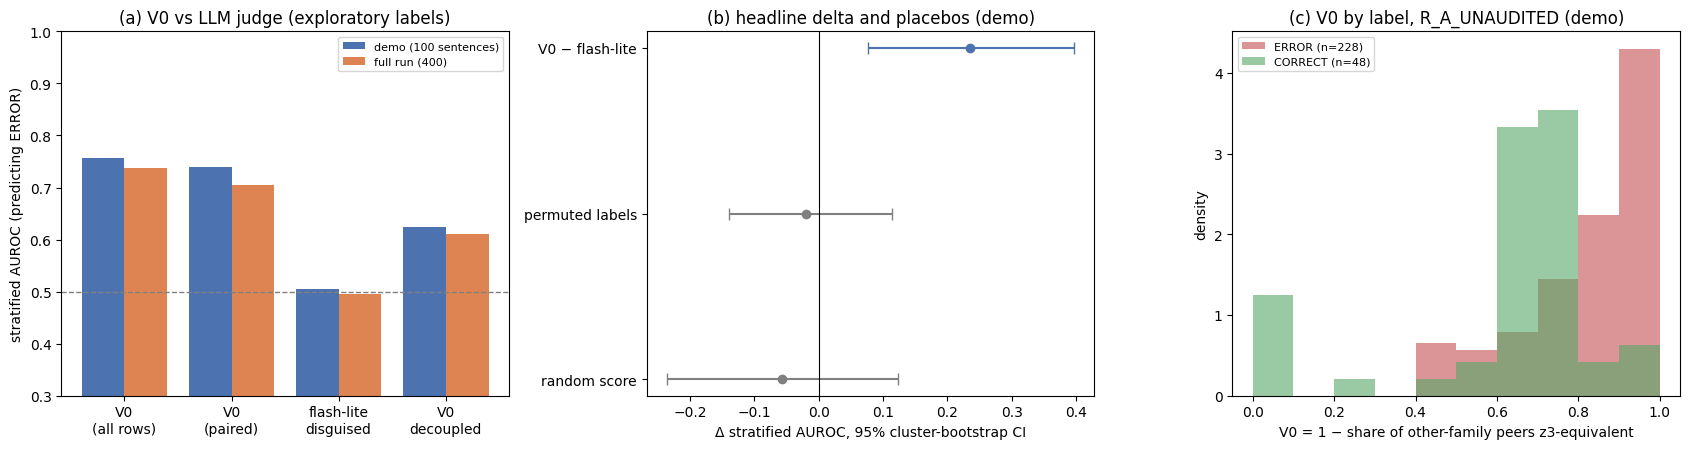

In [13]:
def _f(x):
    if isinstance(x, list): return "[" + ", ".join(f"{v:+.3f}" for v in x) + "]"
    if isinstance(x, float): return f"{x:.3f}"
    return str(x)

ROWS = [
    ("R_A_UNAUDITED n (ERROR/CORRECT)", f"{out['population_R_A_UNAUDITED']['n']} ({out['population_R_A_UNAUDITED']['ERROR']}/{out['population_R_A_UNAUDITED']['CORRECT']})",
     f"{FULL_REF['population_R_A_UNAUDITED']['n']} ({FULL_REF['population_R_A_UNAUDITED']['ERROR']}/{FULL_REF['population_R_A_UNAUDITED']['CORRECT']})"),
    ("V0 strat AUROC", out["V0_strat_auroc"], FULL_REF["V0_strat_auroc"]),
    ("paired n (CORRECT)", f"{out['paired']['n']} ({out['paired']['n_correct']})", f"{FULL_REF['paired']['n']} ({FULL_REF['paired']['n_correct']})"),
    ("  V0 AUROC (paired)", out["paired"]["V0_auroc"], FULL_REF["paired"]["V0_auroc"]),
    ("  flash-lite disg AUROC (paired)", out["paired"]["flashlite_disg_auroc"], FULL_REF["paired"]["flashlite_disg_auroc"]),
    ("  delta V0 - flash-lite", out["paired"]["delta"], FULL_REF["paired"]["delta"]),
    ("  delta 95% CI (cluster bootstrap)", out["paired"]["delta_ci"], FULL_REF["paired"]["delta_ci"]),
    ("placebo: permutation p", out["placebo_permuted_labels"]["permutation_p_two_sided"], FULL_REF["placebo_permuted_labels"]["permutation_p_two_sided"]),
    ("placebo: permuted-label CI", out["placebo_permuted_labels"]["one_permuted_label_bootstrap_ci"], FULL_REF["placebo_permuted_labels"]["one_permuted_label_bootstrap_ci"]),
    ("placebo: random-score CI", out["placebo_random_score_vs_flashlite"]["ci"], FULL_REF["placebo_random_score_vs_flashlite"]["ci"]),
    ("V0_decoupled strat AUROC", out["V0_decoupled_strat_auroc"], FULL_REF["V0_decoupled_strat_auroc"]),
    ("Spearman(V0, flash-lite) [n]", f"{out['concordance_spearman_V0_flashlite']:.3f} [{out['concordance_n']}]",
     f"{FULL_REF['concordance_spearman_V0_flashlite']:.3f} [{FULL_REF['concordance_n']}]"),
] + [(f"rename flip {t} [n]", f"{out['rename_paired_flip'][t]['flip']:.3f} [{out['rename_paired_flip'][t]['n']}]" if t in out["rename_paired_flip"] else "-",
      f"{FULL_REF['rename_paired_flip'][t]['flip']:.3f} [{FULL_REF['rename_paired_flip'][t]['n']}]") for t in ("RENAME_SYN", "RENAME_NONCE")]
print(f"{'quantity':38s} {'demo (' + str(len(EX)) + ' sent.)':>26s} {'full run (400 sent.)':>26s}")
print("-" * 92)
for name, dv, fv in ROWS:
    print(f"{name:38s} {_f(dv):>26s} {_f(fv):>26s}")

fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
# (a) AUROC for predicting ERROR: demo vs full
names = ["V0\n(all rows)", "V0\n(paired)", "flash-lite\ndisguised", "V0\ndecoupled"]
demo_v = [out["V0_strat_auroc"], out["paired"]["V0_auroc"], out["paired"]["flashlite_disg_auroc"], out["V0_decoupled_strat_auroc"]]
full_v = [FULL_REF["V0_strat_auroc"], FULL_REF["paired"]["V0_auroc"], FULL_REF["paired"]["flashlite_disg_auroc"], FULL_REF["V0_decoupled_strat_auroc"]]
x = np.arange(len(names))
ax[0].bar(x - 0.2, demo_v, 0.4, label=f"demo ({len(EX)} sentences)", color="#4C72B0")
ax[0].bar(x + 0.2, full_v, 0.4, label="full run (400)", color="#DD8452")
ax[0].axhline(0.5, color="grey", ls="--", lw=1)
ax[0].set_xticks(x); ax[0].set_xticklabels(names); ax[0].set_ylim(0.3, 1.0)
ax[0].set_ylabel("stratified AUROC (predicting ERROR)"); ax[0].set_title("(a) V0 vs LLM judge (exploratory labels)"); ax[0].legend(fontsize=8)
# (b) delta and placebo CIs
lab_ci = ["V0 − flash-lite", "permuted labels", "random score"]
pts = [out["paired"]["delta"], out["placebo_permuted_labels"]["one_permuted_delta"], out["placebo_random_score_vs_flashlite"]["delta"]]
cis = [out["paired"]["delta_ci"], out["placebo_permuted_labels"]["one_permuted_label_bootstrap_ci"], out["placebo_random_score_vs_flashlite"]["ci"]]
for i, (p_, c_) in enumerate(zip(pts, cis)):
    ax[1].errorbar(p_, i, xerr=[[p_ - c_[0]], [c_[1] - p_]], fmt="o", color=["#4C72B0", "grey", "grey"][i], capsize=4)
ax[1].axvline(0, color="k", lw=0.8)
ax[1].set_yticks(range(3)); ax[1].set_yticklabels(lab_ci); ax[1].invert_yaxis()
ax[1].set_xlabel("Δ stratified AUROC, 95% cluster-bootstrap CI"); ax[1].set_title("(b) headline delta and placebos (demo)")
# (c) V0 distribution by label
v_err = [r["V0"] for r in V if r["label"] == "ERROR"]; v_cor = [r["V0"] for r in V if r["label"] == "CORRECT"]
bins = np.linspace(0, 1, 11)
ax[2].hist(v_err, bins=bins, alpha=0.6, density=True, label=f"ERROR (n={len(v_err)})", color="#C44E52")
ax[2].hist(v_cor, bins=bins, alpha=0.6, density=True, label=f"CORRECT (n={len(v_cor)})", color="#55A868")
ax[2].set_xlabel("V0 = 1 − share of other-family peers z3-equivalent"); ax[2].set_ylabel("density")
ax[2].set_title("(c) V0 by label, R_A_UNAUDITED (demo)"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()